In [ ]:
import torch
from transformers import PreTrainedTokenizerFast, GPT2LMHeadModel, AutoConfig

In [ ]:
MODEL_ID = 'skt/kogpt2-base-v2'

# ⚠️ AutoTokenizer 로 열면 깨진다. 이 모델은 아래 방식으로 연다.
#    아래 다섯 개는 "문장 시작/끝/모르는 글자/자리 채우기/빈칸" 을 뜻하는 특수 토큰 이름이다.
#    KoGPT2 는 이 이름들을 저장소에 적어 두지 않아서, 우리가 열 때 직접 알려 줘야 한다.
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    MODEL_ID,
    bos_token="</s>", eos_token="</s>",
    unk_token="<unk>", pad_token="<pad>", mask_token="<mask>",
)

# .eval() — 학습이 아니라 사용만 할 것이라는 선언. 오늘은 모델을 고치지 않는다.
model = GPT2LMHeadModel.from_pretrained(MODEL_ID).eval()

# GPU 가 있으면 GPU 로, 없으면 CPU 로. 125M 이라 CPU 로도 돌아간다.
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("device :", device)
print("params :", f"{sum(p.numel() for p in model.parameters()):,}") 

Loading weights: 100%|██████████| 149/149 [00:00<00:00, 9963.83it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


device : cuda
params : 125,164,032


In [ ]:
sample = "깊은 산속에 작은 집이"

print("토큰화 : ", tokenizer.tokenize(sample))
print("복원 : " , tokenizer.decode(tokenizer.encode(sample)))

토큰화 :  ['▁깊은', '▁산', '속에', '▁작은', '▁집이']
복원 :  깊은 산속에 작은 집이


In [ ]:
config = AutoConfig.from_pretrained(MODEL_ID)
print(config.vocab_size)          # 모델이 알고있는 토큰(단어)정보의 가짓수 => 51200
print(config.hidden_size)         # 토큰 하나를 벡터화 했을 때 벡터의 길이 
print(config.num_hidden_layers)   # 트랜스포머 블록을 몇번 쌓았느냐
print(config.num_attention_heads) # 멀티헤드어텐션의 헤드 수

51200
768
12
12


In [ ]:
# 모델별 설정 정보 비 교
FAMILY = {
    "BERT (인코더만)":      "klue/bert-base",
    "GPT2 (디코더만)":      "skt/kogpt2-base-v2",
    "BART (인코더+디코더)": "gogamza/kobart-summarization",
}

FIELDS = ["hidden_size", "num_attention_heads", "num_hidden_layers", "vocab_size"]

print(f"{'':22s} {'type':6s} " + " ".join(f"{f:>20s}" for f in FIELDS))
for label, model_id in FAMILY.items():
    c = AutoConfig.from_pretrained(model_id)
    row = " ".join(f"{getattr(c, f):>20,}" for f in FIELDS)
    print(f"{label:22s} {c.model_type:6s} " + row)

# 같은 Body (블록)을 공유하기 때문에 hidden_size는 같지만
# vocab이 다르기 때문에 토크나이저를 섞어서 쓰면 안된다. 

                       type            hidden_size  num_attention_heads    num_hidden_layers           vocab_size
BERT (인코더만)            bert                    768                   12                   12               32,000
GPT2 (디코더만)            gpt2                    768                   12                   12               51,200
BART (인코더+디코더)         bart                    768                   16                    6               30,000


In [ ]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(51200, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=51200, bias=False)
)

In [ ]:
prompt = "깊은 산속에 작은 집이"
input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
output = model(input_ids)
output.logits.shape
output

CausalLMOutputWithCrossAttentions(loss=None, logits=tensor([[[-6.2736, -5.8336, -5.1443,  ...,  1.3125, -4.1601, -2.7672],
         [-4.6140, -4.4556, -5.1378,  ..., -0.1938, -3.1230, -4.0202],
         [-5.1078, -5.5417, -5.4484,  ...,  4.9712, -0.6107,  0.0477],
         [-6.6487, -5.8145, -5.7920,  ...,  3.5639, -6.8394, -5.4803],
         [-5.2026, -6.2109, -4.8163,  ...,  1.5929,  3.8935, -1.3313]]],
       device='cuda:0', grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=None, attentions=None, cross_attentions=None)

In [ ]:
last_logits = output.logits[0, -1]  # 맨 마지막 번째 토큰은 다음 등장할 토큰의 로짓정보

probs = torch.softmax(last_logits, dim=-1) # 다 더하면 1이 되는 확률 정보, 크기 51,200, 순서 안바뀜

top = torch.topk(probs, 5)        # 상위 5개- 확률 정보, 단어사전 인덱스 정보
print(top.indices)
print(prompt, "/ 다음에 올 단어 후보")
for score, idx in zip(top.values, top.indices):
    token = tokenizer.decode(idx)
    print(f"{token!r:>10}, {score.item():%}")
print("전체 합 확률 : ", probs.sum().item())

tensor([9402, 9416, 9029, 9341, 9414], device='cuda:0')
깊은 산속에 작은 집이 / 다음에 올 단어 후보
      '하나', 16.728266%
  '있었다.\n', 7.587093%
   '있다.\n', 7.575712%
      '있어', 3.433280%
      '있었', 2.576587%
전체 합 확률 :  1.0


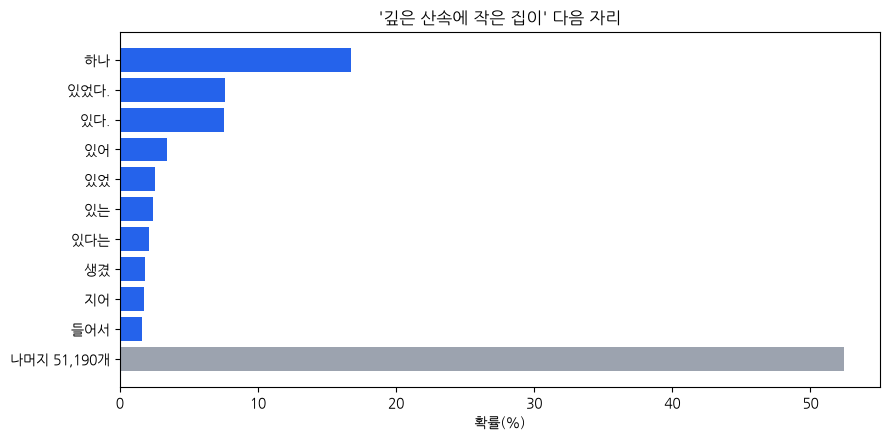

상위 10개 합계 :  47.6%
나머지 51,190개 :  52.4%


In [ ]:
# 📋 붙여넣기 [블록 6] — 내 프롬프트의 확률 분포를 막대로
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 그래프의 한글이 □ 로 깨지지 않게 — 설치된 한글 폰트를 찾아 지정한다.
# matplotlib 기본 폰트에는 한글 글자가 없어서 이 부분이 필요하다.
installed = {f.name for f in font_manager.fontManager.ttflist}
for name in ["NanumGothic", "Noto Sans CJK KR", "Malgun Gothic", "AppleGothic"]:
    if name in installed:
        plt.rcParams["font.family"] = name
        break
plt.rcParams["axes.unicode_minus"] = False   # 한글 폰트에서 마이너스 기호가 깨지는 것 방지


def plot_next_token(text, k=10):
    """text 다음에 올 토큰 상위 k개 + 나머지 전부를 막대로 그린다."""
    ids = tokenizer.encode(text, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(ids).logits[0, -1]
    probs = torch.softmax(logits, dim=-1)

    top = torch.topk(probs, k)
    # 토큰 안의 줄바꿈은 라벨을 깨뜨리므로 지운다
    labels = [tokenizer.decode([i]).replace("\n", "") for i in top.indices.tolist()]
    values = [v * 100 for v in top.values.tolist()]

    rest = 100 - sum(values)                       # 상위 k개를 뺀 나머지 전부
    labels.append(f"나머지 {len(probs) - k:,}개")
    values.append(rest)

    plt.figure(figsize=(9, 4.5))
    plt.barh(range(len(values)), values,
             color=["#2563eb"] * k + ["#9ca3af"])  # 마지막 막대(꼬리)만 회색
    plt.yticks(range(len(values)), labels)
    plt.gca().invert_yaxis()                       # 1등이 맨 위로
    plt.xlabel("확률(%)")
    plt.title(f"'{text}' 다음 자리")
    plt.tight_layout()
    plt.savefig("next_token.png", dpi=120)         # 파일로도 남는다 — 캡처 대신 이걸 내도 된다
    plt.show()

    print(f"상위 {k}개 합계 : {sum(values) - rest:5.1f}%")
    print(f"나머지 {len(probs) - k:,}개 : {rest:5.1f}%")


plot_next_token(prompt)

In [ ]:
# 1. 토큰화 -> 임베딩
ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

print(tokenizer.decode(ids[0]))
# 각 스텝마다 반복해서
for step in range(3):
    with torch.no_grad():
        # 2. 모델을 통과해서 마지막 로짓을 꺼낸다.
        logits = model(ids).logits[0, -1]   # 스텝이 통과할때마다 ids가 연결되어 늘어난다.
        # 3. 가장 확률이 높은 1등을 선택한다.
        next_id = logits.argmax()  
        # 4. 선택된 id를 계속 연결한다. => 연결해서 ids를 늘리고 다시 되돌아간다. (autoregressive)
        ids = torch.cat([ids, next_id.view(1, 1)], dim=1)
        print(f"과정 : {tokenizer.decode(next_id)!r}")
print(f"생성 결과 : {tokenizer.decode(ids[0])}")

깊은 산속에 작은 집이
과정 : '하나'
과정 : '있다.\n'
과정 : '바로'
생성 결과 : 깊은 산속에 작은 집이 하나 있다.
바로


In [ ]:
# 생성 함수
with torch.no_grad():
    # 토큰 인덱스 정보 텐서 생성 반환
    generated = model.generate(
        tokenizer.encode(prompt, return_tensors="pt").to(device), # 입력 임베딩
        max_new_tokens=3,   # 최대 3번 반복. 위 반복문 step 수와 동일
        do_sample=False,    # 샘플링을 하지 않음 => Greedy 알고리즘 최고 확률만 고른다.
        pad_token_id=tokenizer.pad_token_id   # 빈 자리 패딩 자리 채우기
    )


print( tokenizer.decode(generated[0]) ) # generate 함수로 3토큰 생성한 결과
print( tokenizer.decode(ids[0]) )  # 수제 생성 결과와 동일

깊은 산속에 작은 집이 하나 있다.
바로
깊은 산속에 작은 집이 하나 있다.
바로


In [ ]:
# 반복 붕괴 현상 : degeneration
with torch.no_grad():
    generated = model.generate(
        tokenizer.encode(prompt, return_tensors="pt").to(device), 
        max_new_tokens=100,   # 100 회 반복
        do_sample=False,    # 샘플링을 하지 않음 => Greedy 알고리즘 최고 확률만 고른다.
        pad_token_id=tokenizer.pad_token_id   # 빈 자리 패딩 자리 채우기
    )

print( tokenizer.decode(generated[0]) )

깊은 산속에 작은 집이 하나 있다.
바로 이 집은 바로 이 산속에 있는 작은 집이다.
이 집은 바로 이 산속에 있는 작은 집이다.
이 집은 바로 이 산속에 있는 작은 집이다.
이 집은 바로 이 산속에 있는 작은 집이다.
이 집은 바로 이 산속에 있는 작은 집이다.
이 집은 바로 이 산속에 있는 작은 집이다.
이 집은 바로 이 산속에 있는 작은 집이다.
이 집은 바로 이 산속에 있는 작은 집이다.
이 집은 바로 이 산속에 있는 작은 집이다.
이 집은 바로 이 산속에 있는


In [ ]:
def generate(label, max_new_tokens=60, **options):
    """옵션을 바꿔 가며 생성하고 결과를 출력한다.

    **options — 여기로 do_sample, temperature, top_k ... 가 그대로 넘어간다.
                오늘 배울 디코딩 옵션을 바꿔 끼우는 자리다.
    """
    ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(
            ids, max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.pad_token_id, **options,
        )
    # skip_special_tokens=True — </s> 같은 표시를 빼고 사람이 읽을 부분만
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    print(f"=== {label}")
    print(text[len(prompt):].strip(), "\n")   # 프롬프트는 빼고 '이어 쓴 부분'만 보여 준다
    return text

In [ ]:
# 반복 붕괴현상 해결책 -> 반복에 패널티를 준다.
generate(label="그리디, 반복패널티", do_sample=False, repetition_penalty=1.2)

=== 그리디, 반복패널티
하나 있다.
바로 이 집은 바로 '산골마을'이다.
이곳은 마을 전체가 산으로 둘러싸여 있어 마치 산과 들 사이에 있는 듯한 느낌을 준다.
그런데도 이곳은 산이 아니라 산을 배경으로 한 곳이다.
그래서인지 이곳 사람들은 산에 대한 이야기를 많이 한다.
'산에 관한 이야기'는 주로 산에서 일어나는 일들을 다루고 있는데, 그 



"깊은 산속에 작은 집이 하나 있다.\n바로 이 집은 바로 '산골마을'이다.\n이곳은 마을 전체가 산으로 둘러싸여 있어 마치 산과 들 사이에 있는 듯한 느낌을 준다.\n그런데도 이곳은 산이 아니라 산을 배경으로 한 곳이다.\n그래서인지 이곳 사람들은 산에 대한 이야기를 많이 한다.\n'산에 관한 이야기'는 주로 산에서 일어나는 일들을 다루고 있는데, 그"

In [ ]:
# 빔 서치 : 1등만 가져가는 대신, beam 숫자만큼 후보를 동시에 n개 끌고간다.
generate("빔 서치", do_sample=False, num_beams=4)
# 다른 선택지 가능 => 반복붕괴는 이어짐.

=== 빔 서치
하나 있었다.
그 집에는 할머니가 살고 계셨다.
그런데 할머니가 돌아가신 지 얼마 되지 않아 할머니가 돌아가셨다.
그런데 할머니가 돌아가신 지 얼마 되지 않아 할머니가 돌아가셨다.
그런데 할머니가 돌아가신 지 얼마 되지 않아 할머니가 돌아가셨다.
그런데 할머니가 



'깊은 산속에 작은 집이 하나 있었다.\n그 집에는 할머니가 살고 계셨다.\n그런데 할머니가 돌아가신 지 얼마 되지 않아 할머니가 돌아가셨다.\n그런데 할머니가 돌아가신 지 얼마 되지 않아 할머니가 돌아가셨다.\n그런데 할머니가 돌아가신 지 얼마 되지 않아 할머니가 돌아가셨다.\n그런데 할머니가'

In [ ]:
# Greedy 가 항상 나쁜 선택지는 아님 => 머신 번역, 요약 등, 정해진 답을 낼때. 
# 루프에 빠지지 않는 경우 반복붕괴도 없음.

In [ ]:
# 샘플링 -> 랜덤하게 확률로 뽑기
torch.manual_seed(0)  # 랜덤 시드값을 고정
generate("샘플링", do_sample=True)

=== 샘플링
하나 있다.
바로 산자락에 자리잡은 집. 그 집엔 ‘누구보다 내 집을 잘 알고 살지만’ 나는 집 밖에 있는 자신을 찾고 있었다.
그런 나를 위해 그는 나를 찾아 떠났다.
‘누구보다 내 집을 잘 알고 잘 알고’ 살았다.
남다른 내 집 가꾸기와 내 집 지킴 



'깊은 산속에 작은 집이 하나 있다.\n바로 산자락에 자리잡은 집. 그 집엔 ‘누구보다 내 집을 잘 알고 살지만’ 나는 집 밖에 있는 자신을 찾고 있었다.\n그런 나를 위해 그는 나를 찾아 떠났다.\n‘누구보다 내 집을 잘 알고 잘 알고’ 살았다.\n남다른 내 집 가꾸기와 내 집 지킴'

`temperature` 는 확률 분포의 **기울기**를 바꾼다.

| 값 | 분포 | 결과 |
|---|---|---|
| 낮다 (0.2) | **뾰족해진다** — 1등이 더 압도적 | 안전하지만 뻔하다. greedy에 가까워진다 |
| 1.0 | 원래 분포 그대로 | — |
| 높다 (1.5) | **평평해진다** — 하위 후보도 뽑힐 만해진다 | 다양하지만 헛소리 위험 |

**식으로 보면 바뀌는 곳은 한 군데뿐이다.**

$$P_i = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

`## 2` 에서 쓴 softmax 그대로인데, 넣기 전에 로짓을 `T` 로 **한 번 나눌 뿐**이다.
나누면 로짓 사이의 **간격**이 변한다 — 이 자리 실측값으로 보면:

| | 값 |
|---|---|
| 1등 `'하나'` 로짓 | 14.097 |
| 2등 `'있었다.'` 로짓 | 13.307 |
| 차이 | **0.790** |

`T=0.5` 로 나누면 차이가 **1.580** 으로 2배 벌어지고(→ 뾰족),
`T=1.5` 로 나누면 **0.527** 로 좁혀진다(→ 평평).
**온도는 확률을 직접 건드리지 않는다. 점수 사이 간격을 건드린다.**

In [ ]:
# 온도 : 
torch.manual_seed(0) # 랜덤 시드 고정
generate("온도 0.3", do_sample=True, temperature=0.3)
generate("온도 0.5", do_sample=True, temperature=0.5)
generate("온도 1", do_sample=True, temperature=1)
generate("온도 1.5", do_sample=True, temperature=1.5)
# generate("온도 13", do_sample=True, temperature=3)

=== 온도 0.3
하나 있다.
바로 이 작은 집은 '작은 집'이다.
작은 집이란 '작은 집' 혹은 '작은 집' 또는 '작은 집' 또는 '작은 집' 또는 '작은 집' 또는 '작은 집' 또는 '작은 집' 또는 '작은 집' 또는 '작은 집' 또는 '작은 

=== 온도 0.5
하나 있다.
그곳에는 세 개의 방이 있다.
그중 하나는 ‘세 개의 방’으로, 하나는 ‘세 개의 방’으로, 하나는 ‘세 개의 방’으로, 하나는 ‘세 개의 방’으로, 하나는 ‘세 개의 방’으로, 하나는 ‘세 개의 방’으로, 하나는 ‘세 개의 방’으로, 

=== 온도 1
있어 ‘집’을 뜻하는 집어체로 ‘집’을 의미해 ‘집’과 집을 가진다는 것은 건축업계에서 통용되는 말이기 때문이다.
또한 자연친화적 주거환경을 갖춘 주택은 곧 ‘친환경 주거공간’의 이미지로 인식되지만 최근에는 단순한 주거기능이 아닌, 자연과 호흡할 수 있는 

=== 온도 1.5
있었고, 그 옆 마을의 마을사람은 "내일이면 그 집을 지을 터인데..."라고 말을 이었던 것이라며, "제대로 만든다면, 내가 지어 준 집으로 다시 돌아가야겠다"고 말했다.
마을사람들의 말에 따르면, 마을을 건축하던 마을기업인 ( 舊 海村)이 마을을 철거하기 시작했는데, 이를 



'깊은 산속에 작은 집이 있었고, 그 옆 마을의 마을사람은 "내일이면 그 집을 지을 터인데..."라고 말을 이었던 것이라며, "제대로 만든다면, 내가 지어 준 집으로 다시 돌아가야겠다"고 말했다.\n마을사람들의 말에 따르면, 마을을 건축하던 마을기업인 ( 舊 海村)이 마을을 철거하기 시작했는데, 이를'

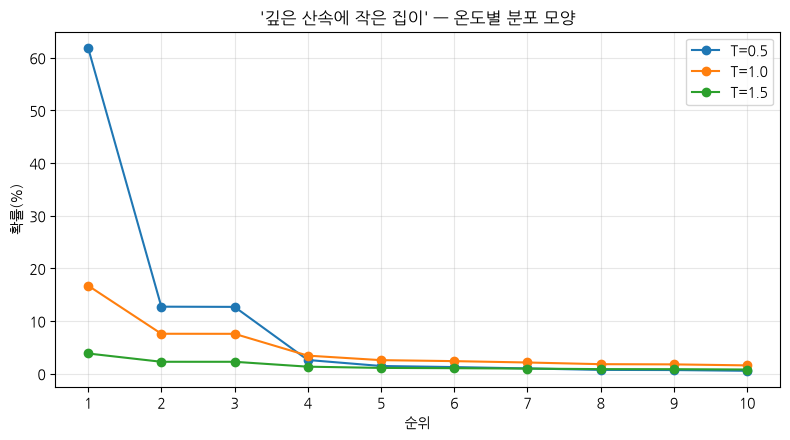

In [ ]:
# 📋 붙여넣기 [블록 7] — 온도가 분포 모양을 바꾸는 것을 그림으로
def plot_temperature(text, temps=(0.5, 1.0, 1.5), k=10):
    """같은 자리에서 T만 바꿔, 상위 k개 순위별 확률을 겹쳐 그린다."""
    ids = tokenizer.encode(text, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(ids).logits[0, -1]

    # 순위는 T=1.0 기준으로 고정한다 — 그래야 세 곡선을 같은 x축에서 비교할 수 있다
    top_ids = torch.topk(torch.softmax(logits, dim=-1), k).indices

    plt.figure(figsize=(8, 4.5))
    for T in temps:
        p = torch.softmax(logits / T, dim=-1)[top_ids] * 100   # 로짓을 T로 나눈 뒤 softmax
        plt.plot(range(1, k + 1), p.tolist(), marker="o", label=f"T={T}")

    plt.xticks(range(1, k + 1))
    plt.xlabel("순위")
    plt.ylabel("확률(%)")
    plt.title(f"'{text}' — 온도별 분포 모양")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("temperature_shape.png", dpi=120)
    plt.show()


plot_temperature(prompt)

In [ ]:
# Top-k : 아주 이상한 토큰들이 뽑힐 확률을 애초에 제거.
# 51200개(vocab size)개를 다 계산하고, 그 중에서 k개를 고르기 때문에, 연산량은 그대로.
torch.manual_seed(0)  # 랜덤 시드 고정
generate("top-k 50", do_sample=True, top_k=50)  # 상위 50개 후보만 뽑는다

# Top-p : 상위 n%까지. 확률 누적으로 n%에 해당되는 후보수 만큼
generate("top-p- 90", do_sample=True, top_p=0.9)  # 상위 90% 후보만 뽑는다

=== top-k 50
하나 있다.
바로 산자락에 자리잡은 집. 그 집엔 ‘누구보다 내 집을 잘 알고 살지만’ 나는 집 밖에 있는 자신을 찾고 있었다.
그런 나를 위해 그는 나를 찾아 떠났다.
‘누구보다 내 집을 잘 알고 잘 알고’ 살았다.
남다른 내 집 가꾸기와 내 집 지킴 

=== top-p- 90
하나 있다.
그곳에는 세 개의 큰 나무가 자리 잡고 있다.
아기들 곁으로 다가가보면 나무 그늘을 만들어주는 나무 그늘이 눈에 띈다.
그곳에서 아이들이 뛰어노는 모습을 본 적이 있는가.
그곳에서 아이들은 한 번도 마주쳐보지 못했다.
아이들은 그 자리를 지날 때마다 엄마의 손을 



'깊은 산속에 작은 집이 하나 있다.\n그곳에는 세 개의 큰 나무가 자리 잡고 있다.\n아기들 곁으로 다가가보면 나무 그늘을 만들어주는 나무 그늘이 눈에 띈다.\n그곳에서 아이들이 뛰어노는 모습을 본 적이 있는가.\n그곳에서 아이들은 한 번도 마주쳐보지 못했다.\n아이들은 그 자리를 지날 때마다 엄마의 손을'

In [ ]:
def cut_report(text, p=0.9, k=5):
    """이 자리에서 top-k와 top-p가 각각 무엇을 남기는지 센다."""
    ids = tokenizer.encode(text, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(ids).logits[0, -1]

    probs = torch.softmax(logits, dim=-1)
    sorted_probs, sorted_ids = torch.sort(probs, descending=True)   # 순서대로 내림차순 정렬
    cumulative = torch.cumsum(sorted_probs, dim=0)

    kept_by_p = int((cumulative < p).sum().item()) + 1   # 누적이 p를 넘는 순간까지
    mass_by_k = cumulative[k - 1].item() * 100           # 상위 k개가 담는 확률

    print(f"...{text[-12:]!r}")
    print(f"   1등            : {tokenizer.decode([sorted_ids[0]])!r} {sorted_probs[0]*100:.1f}%")
    print(f"   top_k={k} 가 담는 확률 : {mass_by_k:.1f}%")
    print(f"   top_p={p} 가 남기는 후보 : {kept_by_p:,}개\n")


cut_report("오늘 아침 날씨는 어제보다 더 춥겠습니")   # 다음이 뻔한 자리
cut_report("깊은 산속에 작은 집이")                  # 다음이 애매한 자리

...' 어제보다 더 춥겠습니'
   1등            : '다' 50.0%
   top_k=5 가 담는 확률 : 92.0%
   top_p=0.9 가 남기는 후보 : 4개

...'깊은 산속에 작은 집이'
   1등            : '하나' 16.7%
   top_k=5 가 담는 확률 : 37.9%
   top_p=0.9 가 남기는 후보 : 298개



In [ ]:
config.max_position_embeddings

1024

In [ ]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(51200, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  )
  (lm_head): Linear(in_features=768, out_features=51200, bias=False)
)

In [ ]:
!uv pip install openai

Using Python 3.12.13 environment at: /home/pc16/p3-llm/c2-transformer/.venv
Resolved 16 packages in 586ms                                        
Prepared 11 packages in 350ms                                                openai               ------------------------------ 1.20 MiB/1.59 MiB           pydantic-core        ------------------------------ 765.75 KiB/2.00 MiB         pydantic-core        ------------------------------ 349.75 KiB/2.00 MiB         pydantic-core        ------------------------------ 93.65 KiB/2.00 MiB          pydantic-core        ------------------------------ 93.65 KiB/2.00 MiB          pydantic-core        ------------------------------ 16.89 KiB/2.00 MiB          pydantic-core        ------------------------------ 16.89 KiB/2.00 MiB          pydantic-core        ------------------------------ 16.00 KiB/2.00 MiB          mpydantic-core        ------------------------------     0 B/2.00 MiB            ydantic-core        ------------------------------     0

In [ ]:
from openai import OpenAI
client = OpenAI()

